In [1]:
%cd ..

import ast

import matplotlib.pyplot as plt
import pandas as pd

/Users/yugisu/Personal/visual-geolocalization/diffusion-vpr


/Users/yugisu/Personal/visual-geolocalization/diffusion-vpr/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
df = pd.read_csv("results/1-baseline-comparison.csv")

# Drop exact duplicates
df = df.drop_duplicates()

df

,model,model_extra,dataset,dataset_extra,emb_dim,n_gallery,n_query,retriever_type,Recall@1,Recall@5,Recall@10
0,facebook/dinov3-vitb16-pretrain-lvd1689m,{},visloc,"{'flight_id': '03', 'chunk_pixels': 256, 'chun...",768,2860,768,ip,0.339844,0.587240,0.673177
1,facebook/dinov3-vith16plus-pretrain-lvd1689m,{},visloc,"{'flight_id': '03', 'chunk_pixels': 256, 'chun...",1280,2860,768,ip,0.337240,0.580729,0.666667
2,facebook/dinov2-large,{},visloc,"{'flight_id': '03', 'chunk_pixels': 512, 'chun...",1024,2860,768,ip,0.225260,0.384115,0.506510
3,MVRL/remote-clip-vit-base-patch32,{},visloc,"{'flight_id': '03', 'chunk_pixels': 512, 'chun...",512,2860,768,ip,0.070312,0.179688,0.253906
4,diffusionsat,"{'embedder': 'PoolConcatEmbedder', 'img_size':...",visloc,"{'flight_id': '03', 'chunk_pixels': 512, 'chun...",8960,2860,768,ip,0.023438,0.041667,0.058594
5,facebook/dinov3-vitl16-pretrain-sat493m,{},visloc,"{'flight_id': '03', 'chunk_pixels': 512, 'chun...",1024,2860,768,ip,0.019531,0.062500,0.079427
7,diffusionsat,"{'embedder': 'PoolConcatEmbedder', 'img_size':...",visloc,"{'flight_id': '03', 'chunk_pixels': 512, 'chun...",6720,2860,768,ip,0.014323,0.046875,0.076823
8,MVRL/rvsa_vitae_b,"{'method': 'forward_encoder,CLS token'}",visloc,"{'flight_id': '03', 'chunk_pixels': 256, 'chun...",768,2860,768,ip,0.009115,0.011719,0.016927
9,diffusionsat,"{'embedder': 'PoolConcatEmbedder', 'img_size':...",visloc,"{'flight_id': '03', 'chunk_pixels': 512, 'chun...",51840,2860,768,ip,0.003906,0.020833,0.035156
10,sd2-community/stable-diffusion-2-1,"{'embedder': 'PoolConcatEmbedder', 'img_size':...",visloc,"{'flight_id': '03', 'chunk_pixels': 512, 'chun...",8960,2860,768,ip,0.003906,0.015625,0.029948


In [3]:
def make_label(row):
  model = row["model"]
  # Shorten common prefixes
  model = model.replace("facebook/", "").replace("MVRL/", "").replace("sd2-community/", "")

  if model == "diffusionsat":
    try:
      extra = ast.literal_eval(row["model_extra"])
    except Exception:
      extra = {}
    ts = extra.get("save_timesteps", "?")
    layers = extra.get("layer_idxs", {})
    block = "down" if "down_blocks" in layers else "up" if "up_blocks" in layers else "?"
    mode = extra.get("diffusion_mode", "?")
    return f"diffusionsat\n{block}_blocks ts={ts}\n{mode}"

  return model


df["label"] = df.apply(make_label, axis=1)

# Sort by Recall@1 descending
df = df.sort_values("Recall@1", ascending=False).reset_index(drop=True)

df[["label", "Recall@1", "Recall@5", "Recall@10"]]

,label,Recall@1,Recall@5,Recall@10
0,dinov3-vitb16-pretrain-lvd1689m,0.339844,0.587240,0.673177
1,dinov3-vith16plus-pretrain-lvd1689m,0.337240,0.580729,0.666667
2,dinov2-large,0.225260,0.384115,0.506510
3,remote-clip-vit-base-patch32,0.070312,0.179688,0.253906
4,"diffusionsat\ndown_blocks ts=[8, 7]\ninversion",0.023438,0.041667,0.058594
5,dinov3-vitl16-pretrain-sat493m,0.019531,0.062500,0.079427
6,"diffusionsat\nup_blocks ts=[7, 8]\ngeneration",0.014323,0.046875,0.076823
7,rvsa_vitae_b,0.009115,0.011719,0.016927
8,"diffusionsat\nup_blocks ts=[47, 45, 40]\ninver...",0.003906,0.020833,0.035156
9,stable-diffusion-2-1,0.003906,0.015625,0.029948


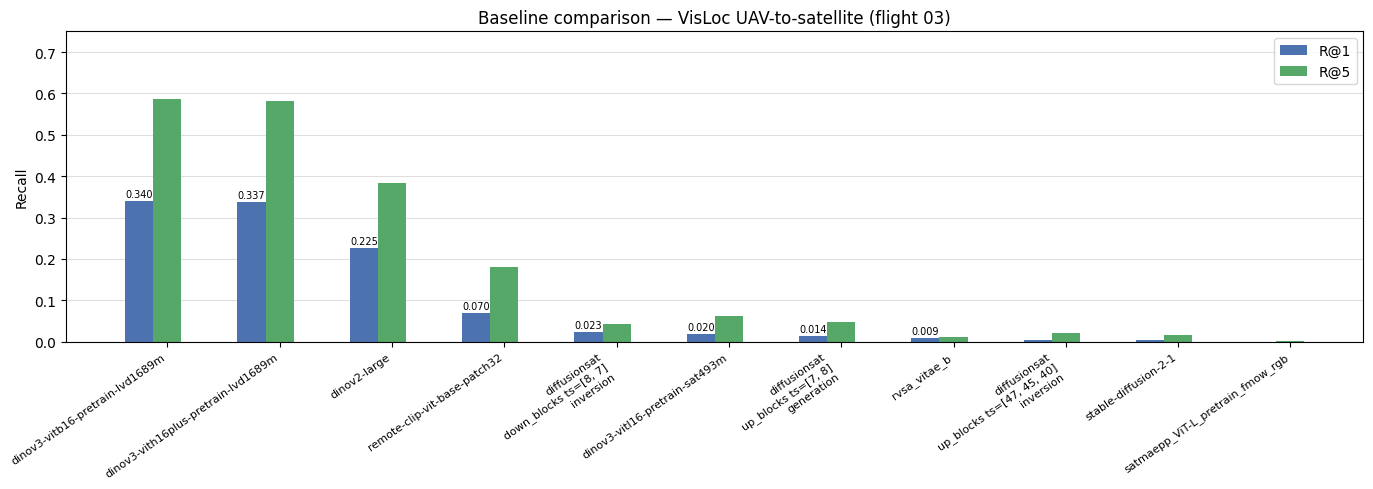

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(df))
width = 0.25

bars1 = ax.bar([i - width for i in x], df["Recall@1"], width, label="R@1", color="#4C72B0")
bars5 = ax.bar([i for i in x], df["Recall@5"], width, label="R@5", color="#55A868")

ax.set_xticks(list(x))
ax.set_xticklabels(df["label"], fontsize=8, ha="right", rotation=35)
ax.set_ylabel("Recall")
ax.set_title("Baseline comparison — VisLoc UAV-to-satellite (flight 03)")
ax.legend()
ax.set_ylim(0, 0.75)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Annotate R@1 values on top of first bar group
for bar in bars1:
  h = bar.get_height()
  if h > 0.005:
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("results/1-baseline-comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Table view
display_cols = ["label", "emb_dim", "Recall@1", "Recall@5", "Recall@10"]
styled = (
  df[display_cols]
  .rename(columns={"label": "model"})
  .style.format({"Recall@1": "{:.3f}", "Recall@5": "{:.3f}", "Recall@10": "{:.3f}"})
  .background_gradient(subset=["Recall@1", "Recall@5", "Recall@10"], cmap="YlGn")
  .hide(axis="index")
)
styled

model,emb_dim,Recall@1,Recall@5,Recall@10
dinov3-vitb16-pretrain-lvd1689m,768,0.340,0.587,0.673
dinov3-vith16plus-pretrain-lvd1689m,1280,0.337,0.581,0.667
dinov2-large,1024,0.225,0.384,0.507
remote-clip-vit-base-patch32,512,0.070,0.180,0.254
"diffusionsat down_blocks ts=[8, 7] inversion",8960,0.023,0.042,0.059
dinov3-vitl16-pretrain-sat493m,1024,0.020,0.062,0.079
"diffusionsat up_blocks ts=[7, 8] generation",6720,0.014,0.047,0.077
rvsa_vitae_b,768,0.009,0.012,0.017
"diffusionsat up_blocks ts=[47, 45, 40] inversion",51840,0.004,0.021,0.035
stable-diffusion-2-1,8960,0.004,0.016,0.030
